# CXR-MultiQuant — Phase 1: Data Preparation
Using a CheXpert-style negation-aware labeler with **weighted severity scoring** to generate labels from radiology reports.

In [30]:
# install everything we need
!pip install datasets pandas scikit-learn matplotlib

In [31]:
# grab the dataset from hugging face
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("itsanmolgupta/mimic-cxr-dataset")
df = dataset['train'].to_pandas()

print(f"Loaded {len(df)} records")
print(f"Columns: {list(df.columns)}")
df[['findings', 'impression']].head(3)

Loaded 30633 records
Columns: ['image', 'findings', 'impression']


,findings,impression
0,"The lungs are clear of focal consolidation, pl...",No acute cardiopulmonary process.
1,Lung volumes remain low. There are innumerable...,Low lung volumes and mild pulmonary vascular c...
2,Lung volumes are low. This results in crowding...,Innumerable pulmonary metastases. Possible mil...


In [32]:
# quick check — how many reports are missing text?
print("Missing values:")
print(df[['findings', 'impression']].isnull().sum())
print(f"\nTotal usable rows: {df['impression'].notna().sum()}")

Missing values:
findings       0
impression    10
dtype: int64

Total usable rows: 30623


## CheXpert-Style Labeler (Weighted + Sentence-Level Negation)

**Improvements over naive keyword matching:**
1. Tracks **12 real CheXpert medical conditions** with synonym keywords
2. **Sentence-level negation** — "No pneumonia. Pleural effusion noted." correctly ignores pneumonia but detects effusion
3. **Weighted severity** — a Pneumothorax (weight 3) is far more dangerous than mild Atelectasis (weight 1)
4. Severity is derived from **total weight score**, not just condition count

| Weight | Conditions | Why |
|--------|-----------|-----|
| **3 (Critical)** | Pneumothorax, Edema, Consolidation | Life-threatening, need immediate treatment |
| **2 (Significant)** | Pneumonia, Lung Opacity, Cardiomegaly, Enlarged Cardiomediastinum | Serious but not immediately fatal |
| **1 (Minor)** | Atelectasis, Pleural Effusion, Lung Lesion, Fracture, Pleural Other | Common, often incidental findings |

**Severity thresholds:**
- Score **0** → Mild
- Score **1–2** → Moderate
- Score **3+** → Severe

In [33]:
import re

# 12 CheXpert conditions with synonym keywords and clinical severity weights
# (excluding 'No Finding' and 'Support Devices' since those aren't diseases)

CHEXPERT_CONDITIONS = {
    # CRITICAL (weight 3) — life-threatening, need immediate intervention
    'Pneumothorax':                {'keywords': ['pneumothorax'], 'weight': 3},
    'Edema':                       {'keywords': ['edema', 'pulmonary edema', 'vascular congestion', 'fluid overload', 'interstitial edema'], 'weight': 3},
    'Consolidation':               {'keywords': ['consolidation', 'consolidated', 'consolidative'], 'weight': 3},

    # SIGNIFICANT (weight 2) — serious conditions
    'Pneumonia':                   {'keywords': ['pneumonia', 'infectious process', 'infection'], 'weight': 2},
    'Lung Opacity':                {'keywords': ['lung opacity', 'opacification', 'opacities', 'airspace opacity'], 'weight': 2},
    'Cardiomegaly':                {'keywords': ['cardiomegaly', 'enlarged heart', 'cardiac enlargement', 'heart is enlarged'], 'weight': 2},
    'Enlarged Cardiomediastinum':   {'keywords': ['enlarged cardiomediastinum', 'widened mediastinum', 'mediastinal widening'], 'weight': 2},

    # MINOR (weight 1) — common or incidental findings
    'Atelectasis':                 {'keywords': ['atelectasis', 'atelectatic'], 'weight': 1},
    'Pleural Effusion':            {'keywords': ['pleural effusion', 'effusions', 'effusion'], 'weight': 1},
    'Lung Lesion':                 {'keywords': ['lung lesion', 'mass', 'nodule', 'nodules', 'tumor'], 'weight': 1},
    'Fracture':                    {'keywords': ['fracture', 'fractured', 'rib fracture'], 'weight': 1},
    'Pleural Other':               {'keywords': ['pleural thickening', 'pleural abnormality', 'pleural calcification'], 'weight': 1},
}

# negation phrases — if these appear before a condition IN THE SAME SENTENCE, condition is not present
NEGATION_PHRASES = [
    'no evidence of', 'no signs of', 'no sign of', 'without',
    'negative for', 'absence of', 'no', 'not', 'clear of',
    'free of', 'resolved', 'unlikely', 'rule out', 'rules out',
    'no definite', 'no acute', 'no significant',
]

print(f"Tracking {len(CHEXPERT_CONDITIONS)} medical conditions")
print(f"Using {len(NEGATION_PHRASES)} negation patterns")

Tracking 12 medical conditions
Using 17 negation patterns


In [34]:
def split_into_sentences(text):
    """Split text into sentences. Handles periods, semicolons, and newlines."""
    sentences = re.split(r'[.;\n]+', text)
    return [s.strip() for s in sentences if s.strip()]


def is_negated_in_sentence(sentence, keyword_pos):
    """Check if a keyword at the given position is negated within this sentence."""
    prefix = sentence[:keyword_pos].lower()
    return any(neg in prefix for neg in NEGATION_PHRASES)


def extract_positive_conditions(impression_text):
    """Finds which conditions are actually present (not negated) in the text.
    
    Key improvement: negation is checked per-sentence, so
    'No pneumonia. Pleural effusion noted.' correctly detects effusion.
    """
    if not isinstance(impression_text, str) or len(impression_text.strip()) == 0:
        return []

    sentences = split_into_sentences(impression_text.lower())
    found_conditions = set()

    for sentence in sentences:
        for condition, info in CHEXPERT_CONDITIONS.items():
            if condition in found_conditions:
                continue

            for keyword in info['keywords']:
                pos = sentence.find(keyword)
                if pos == -1:
                    continue

                if not is_negated_in_sentence(sentence, pos):
                    found_conditions.add(condition)
                break

    return list(found_conditions)


def get_severity_score(conditions_list):
    """Calculate total weighted severity score from detected conditions."""
    return sum(CHEXPERT_CONDITIONS[c]['weight'] for c in conditions_list)


def get_severity(conditions_list):
    """Derive severity label from weighted score.
    Score 0     → Mild
    Score 1-2   → Moderate
    Score 3+    → Severe
    """
    score = get_severity_score(conditions_list)
    if score == 0:
        return 'Mild'
    elif score <= 2:
        return 'Moderate'
    else:
        return 'Severe'


# === SANITY CHECK ===
test_cases = [
    "No acute cardiopulmonary process.",
    "Large bilateral pleural effusions with pulmonary edema.",
    "No evidence of pneumonia. Small pleural effusion noted.",
    "Normal heart size. Clear lungs.",
    "Pneumothorax identified. No fracture.",
    "Mild atelectasis at the bases.",
]

print("=" * 70)
print("SANITY CHECK — sentence-level negation + weighted severity")
print("=" * 70)
for text in test_cases:
    conditions = extract_positive_conditions(text)
    score = get_severity_score(conditions)
    severity = get_severity(conditions)
    print(f"\nText: \"{text}\"")
    print(f"  Conditions: {conditions if conditions else 'None'}")
    print(f"  Weight score: {score}")
    print(f"  Severity: {severity}")

SANITY CHECK — sentence-level negation + weighted severity

Text: "No acute cardiopulmonary process."
  Conditions: None
  Weight score: 0
  Severity: Mild

Text: "Large bilateral pleural effusions with pulmonary edema."
  Conditions: ['Pleural Effusion', 'Edema']
  Weight score: 4
  Severity: Severe

Text: "No evidence of pneumonia. Small pleural effusion noted."
  Conditions: ['Pleural Effusion']
  Weight score: 1
  Severity: Moderate

Text: "Normal heart size. Clear lungs."
  Conditions: None
  Weight score: 0
  Severity: Mild

Text: "Pneumothorax identified. No fracture."
  Conditions: ['Pneumothorax']
  Weight score: 3
  Severity: Severe

Text: "Mild atelectasis at the bases."
  Conditions: ['Atelectasis']
  Weight score: 1
  Severity: Moderate


In [35]:
# apply the labeler to the entire dataset

df['conditions'] = df['impression'].apply(extract_positive_conditions)
df['severity_score'] = df['conditions'].apply(get_severity_score)
df['num_conditions'] = df['conditions'].apply(len)
df['severity'] = df['conditions'].apply(get_severity)

print(f"Labeled all {len(df)} records.\n")
print("Severity distribution:")
print(df['severity'].value_counts())
print(f"\nAverage conditions per report: {df['num_conditions'].mean():.2f}")
print(f"Average severity score: {df['severity_score'].mean():.2f}")

Labeled all 30633 records.

Severity distribution:
severity
Mild        12846
Severe      11795
Moderate     5992
Name: count, dtype: int64

Average conditions per report: 1.12
Average severity score: 2.08


In [36]:
# which conditions show up the most?

from collections import Counter

all_conditions = [c for cond_list in df['conditions'] for c in cond_list]
condition_counts = Counter(all_conditions).most_common()

print("Most common conditions found across all reports:")
print("-" * 50)
for condition, count in condition_counts:
    w = CHEXPERT_CONDITIONS[condition]['weight']
    label = {1: 'Minor', 2: 'Significant', 3: 'Critical'}[w]
    print(f"  {condition}: {count}  (weight: {w} — {label})")

Most common conditions found across all reports:
--------------------------------------------------
  Pleural Effusion: 6694  (weight: 1 — Minor)
  Atelectasis: 6538  (weight: 1 — Minor)
  Edema: 6263  (weight: 3 — Critical)
  Pneumonia: 4745  (weight: 2 — Significant)
  Lung Opacity: 4148  (weight: 2 — Significant)
  Cardiomegaly: 1979  (weight: 2 — Significant)
  Consolidation: 1612  (weight: 3 — Critical)
  Pneumothorax: 1394  (weight: 3 — Critical)
  Lung Lesion: 466  (weight: 1 — Minor)
  Fracture: 281  (weight: 1 — Minor)
  Pleural Other: 87  (weight: 1 — Minor)
  Enlarged Cardiomediastinum: 81  (weight: 2 — Significant)


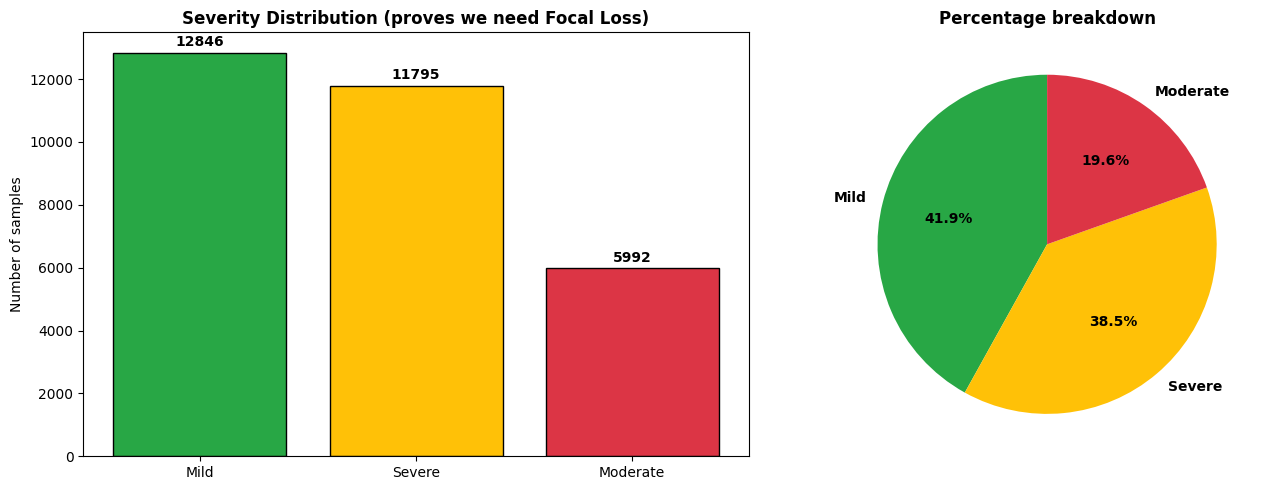

In [37]:
# visualize the class imbalance
import matplotlib.pyplot as plt

counts = df['severity'].value_counts()
colors = ['#28a745', '#ffc107', '#dc3545']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# bar chart
bars = ax1.bar(counts.index, counts.values, color=colors, edgecolor='black')
ax1.set_title('Severity Distribution (proves we need Focal Loss)', fontweight='bold')
ax1.set_ylabel('Number of samples')
for bar, count in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             str(count), ha='center', fontweight='bold')

# pie chart
ax2.pie(counts.values, labels=counts.index, colors=colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontweight': 'bold'})
ax2.set_title('Percentage breakdown', fontweight='bold')

plt.tight_layout()
plt.show()

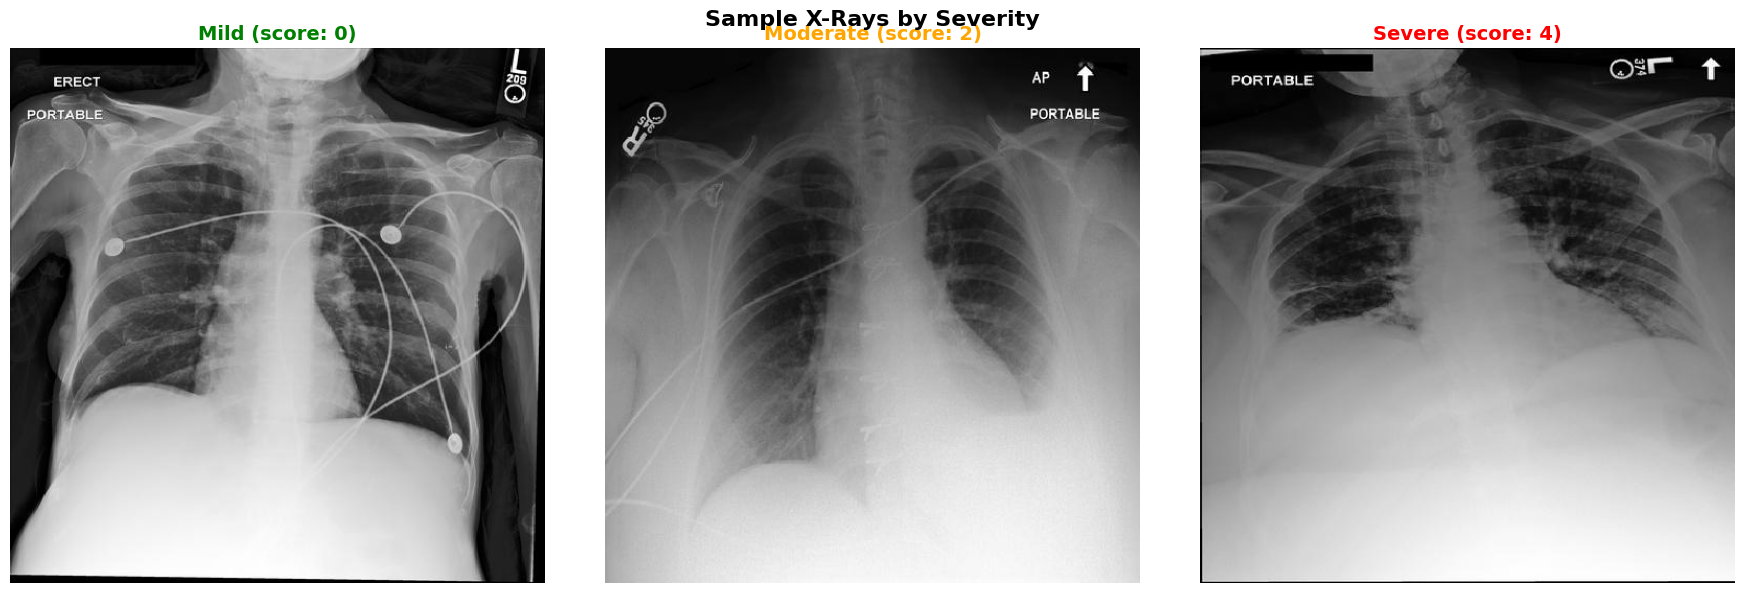


[MILD] (score: 0)
  Impression: No acute cardiopulmonary process.
  Detected: []

[MODERATE] (score: 2)
  Impression: New moderate left pleural effusion with adjacent atelectasis in the left lung base.
  Detected: ['Atelectasis', 'Pleural Effusion']

[SEVERE] (score: 4)
  Impression: Low lung volumes and mild pulmonary vascular congestion is unchanged. New small right fissural pleural effusion. No new focal opacities to suggest pneumonia.
  Detected: ['Pleural Effusion', 'Edema']


In [38]:
# look at actual X-rays — one per severity category
import matplotlib.pyplot as plt
import numpy as np
import io
from PIL import Image

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Sample X-Rays by Severity', fontsize=16, fontweight='bold')

label_colors = {'Mild': 'green', 'Moderate': 'orange', 'Severe': 'red'}

def get_image(img_data):
    # Handle Hugging Face image dictionary format from to_pandas()
    if isinstance(img_data, dict) and 'bytes' in img_data:
        return Image.open(io.BytesIO(img_data['bytes']))
    return img_data

for idx, severity in enumerate(['Mild', 'Moderate', 'Severe']):
    sample = df[df['severity'] == severity].iloc[0]
    img = get_image(sample['image'])
    axes[idx].imshow(np.array(img), cmap='gray')
    axes[idx].set_title(f"{severity} (score: {sample['severity_score']})",
                        fontsize=14, fontweight='bold', color=label_colors[severity])
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# print the impressions + detected conditions
for severity in ['Mild', 'Moderate', 'Severe']:
    sample = df[df['severity'] == severity].iloc[0]
    print(f"\n[{severity.upper()}] (score: {sample['severity_score']})")
    print(f"  Impression: {sample['impression']}")
    print(f"  Detected: {sample['conditions']}")

In [39]:
# 80/10/10 train/val/test split with stratified sampling
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df['severity']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['severity']
)

print(f"Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

# make sure the severity ratio is preserved
print("\nDistribution sanity check:")
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = split['severity'].value_counts(normalize=True) * 100
    print(f"  {name}: Mild={dist.get('Mild',0):.1f}% | Moderate={dist.get('Moderate',0):.1f}% | Severe={dist.get('Severe',0):.1f}%")

Train: 24506 (80.0%)
Val:   3063 (10.0%)
Test:  3064 (10.0%)

Distribution sanity check:
  Train: Mild=41.9% | Moderate=19.6% | Severe=38.5%
  Val: Mild=41.9% | Moderate=19.6% | Severe=38.5%
  Test: Mild=41.9% | Moderate=19.5% | Severe=38.5%


In [40]:
# save everything — images will be loaded dynamically from HF during training
train_df[['findings', 'impression', 'severity']].to_csv('train_labels.csv', index=False)
val_df[['findings', 'impression', 'severity']].to_csv('val_labels.csv', index=False)
test_df[['findings', 'impression', 'severity']].to_csv('test_labels.csv', index=False)

print("Saved: train_labels.csv, val_labels.csv, test_labels.csv")
print("\n" + "=" * 50)
print("PHASE 1 COMPLETE — data is ready for model training")
print("=" * 50)

Saved: train_labels.csv, val_labels.csv, test_labels.csv

PHASE 1 COMPLETE — data is ready for model training
